In [1]:
import os
# Jupyter kernels often don't inherit the shell PATH, so Homebrew's R isn't
# found and rpy2 can't determine R_HOME. Make it discoverable before importing.
if "/opt/homebrew/bin" not in os.environ.get("PATH", ""):
    os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

# The prebuilt rpy2 wheel's "API mode" binary is linked against the CRAN
# R.framework, which isn't installed (this machine uses Homebrew R). Force ABI
# mode so rpy2 resolves R at runtime from R_HOME and skips the failing API
# import (otherwise it prints a benign-but-noisy dlopen error before falling
# back). Must be set before rpy2 is imported below.
os.environ["RPY2_CFFI_MODE"] = "ABI"

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
sns.set_theme()

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

# Enables the %%R cell magic used below to fit the lme4/lmerTest model.
%load_ext rpy2.ipython

In [2]:
# data = pd.read_csv('Veyru Learnability Runs (15 rounds, fork, +10 rounds) - run_level.csv', converters={'string':eval})
SHEET_ID = '1AY1z_UUOasvN1Lmow7rj18QysKoW1uOl0K65q7gNiyg'
GID = '810690606'
csv_url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}'
data = pd.read_csv(csv_url, converters={'string': eval})

data.head()

,run_id,scenario,phase,src_id,field_observer_model,engineer_model,model_class,observer_model,postmortem,round_time_budget_seconds,random_seed,history,rounds_after_swap,total_rounds,round_success_count,round_success_after_resume,perplexity,mcm,labels
0,veyru/1779908251,veyru,baseline,veyru/1779908251,gpt-5.4,gpt-5.4,closed,NaN,True,250,False,NaN,NaN,15,6,NaN,6.296312,80.469388,protocol_learnability|phase=baseline|budget=25...
1,veyru/1781742279,veyru,replace_cross_family,veyru/1779908251,gpt-5.4,gpt-5.4,closed,opus47,True,250,False,10.0,10.0,25,9,0.272727,6.771925,59.654206,protocol_learnability|phase=replace_cross_fami...
2,veyru/1781742283,veyru,replace_cross_family,veyru/1779908251,gpt-5.4,gpt-5.4,closed,opus47,True,250,False,10.0,10.0,25,8,0.181818,6.562687,63.867347,protocol_learnability|phase=replace_cross_fami...
3,veyru/1781742284,veyru,replace_cross_family,veyru/1779908251,gpt-5.4,gpt-5.4,closed,opus47,True,250,False,10.0,10.0,25,10,0.363636,6.593640,66.680851,protocol_learnability|phase=replace_cross_fami...
4,veyru/1781715285,veyru,replace_learned,veyru/1779908251,gpt-5.4,gpt-5.4,closed,NaN,True,250,False,10.0,10.0,25,8,0.181818,6.573100,66.770000,protocol_learnability|phase=replace_learned|bu...


<Axes: xlabel='round_success_after_resume', ylabel='phase'>

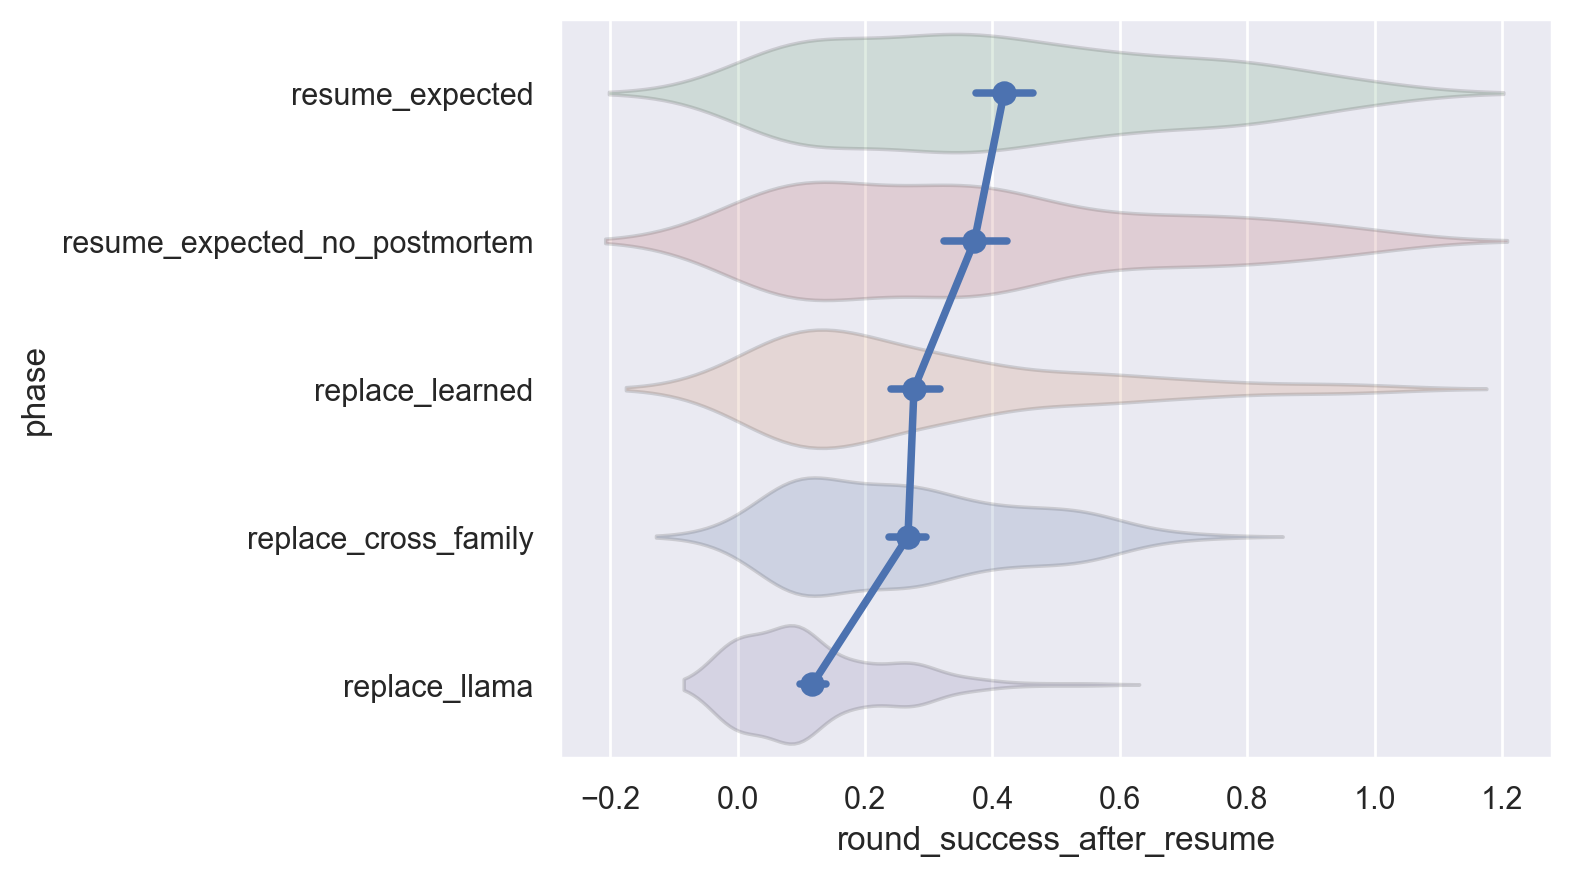

In [3]:
sns.violinplot(data=data[(data['phase'] != 'baseline') & (data['history'] == 10)],
              x='round_success_after_resume', y='phase', hue='phase',
              order=['resume_expected', 'resume_expected_no_postmortem', 'replace_learned',
                                        'replace_cross_family', 'replace_llama'], alpha=0.2, inner=None)
sns.pointplot(data=data[(data['phase'] != 'baseline') & (data['history'] == 10)],
              x='round_success_after_resume', y='phase', ci=95)

<Axes: xlabel='history', ylabel='round_success_after_resume'>

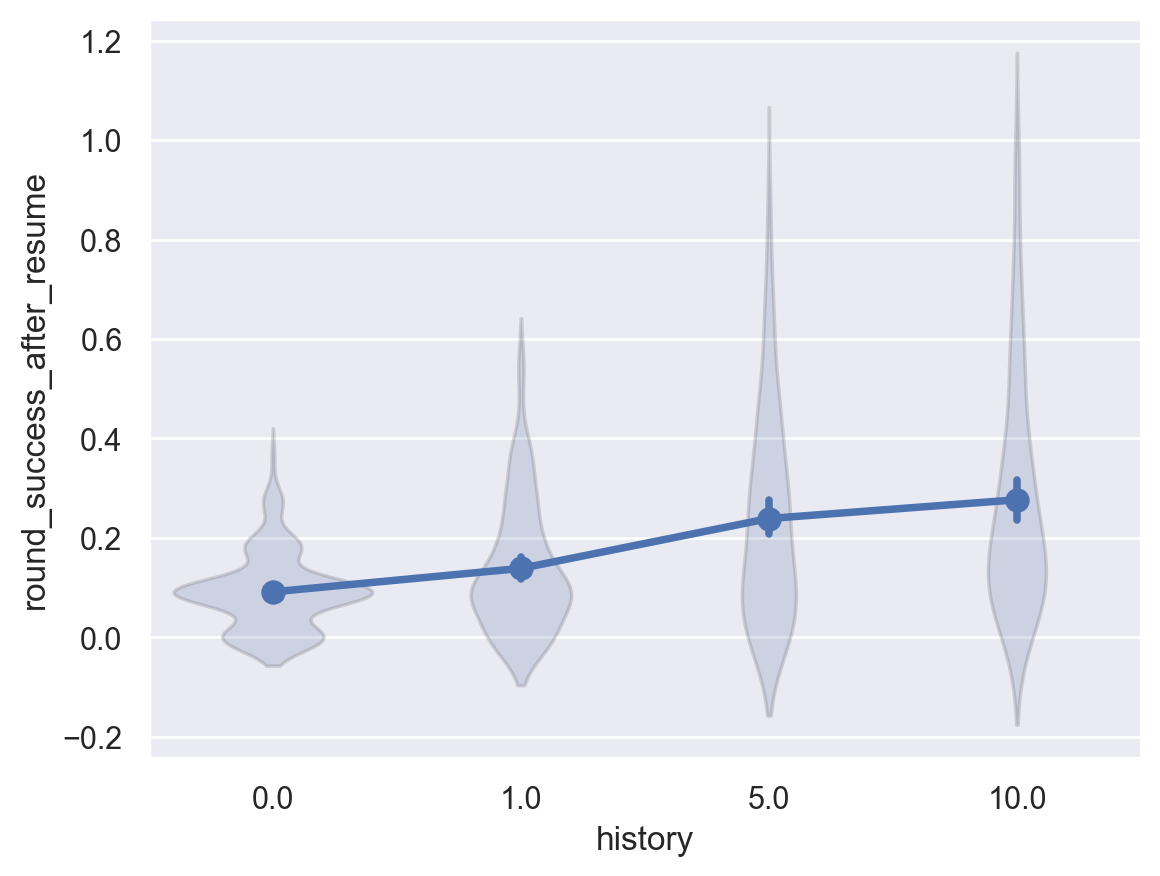

In [4]:
sns.pointplot(data=data[(data['phase'] == 'replace_learned')],
              x='history', y='round_success_after_resume', ci=95)
sns.violinplot(data=data[(data['phase'] == 'replace_learned')],
              x='history', y='round_success_after_resume', inner=None, alpha=0.2)


In [5]:
%%R -i data
library(lme4)
library(lmerTest)

summary(lmer(data=subset(data, phase == 'replace_learned'),
    round_success_after_resume ~ history + (1|src_id)))

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: round_success_after_resume ~ history + (1 | src_id)
   Data: subset(data, phase == "replace_learned")

REML criterion at convergence: -534.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8049 -0.6305 -0.0904  0.5059  3.4078 

Random effects:
 Groups   Name        Variance Std.Dev.
 src_id   (Intercept) 0.01350  0.1162  
 Residual             0.01741  0.1320  
Number of obs: 540, groups:  src_id, 45

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 1.145e-01  1.912e-02 5.321e+01   5.987 1.87e-07 ***
history     1.802e-02  1.442e-03 4.940e+02  12.493  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
        (Intr)
history -0.302


Loading required package: Matrix

Attaching package: ‘lmerTest’

The following object is masked from ‘package:lme4’:

    lmer

The following object is masked from ‘package:stats’:

    step



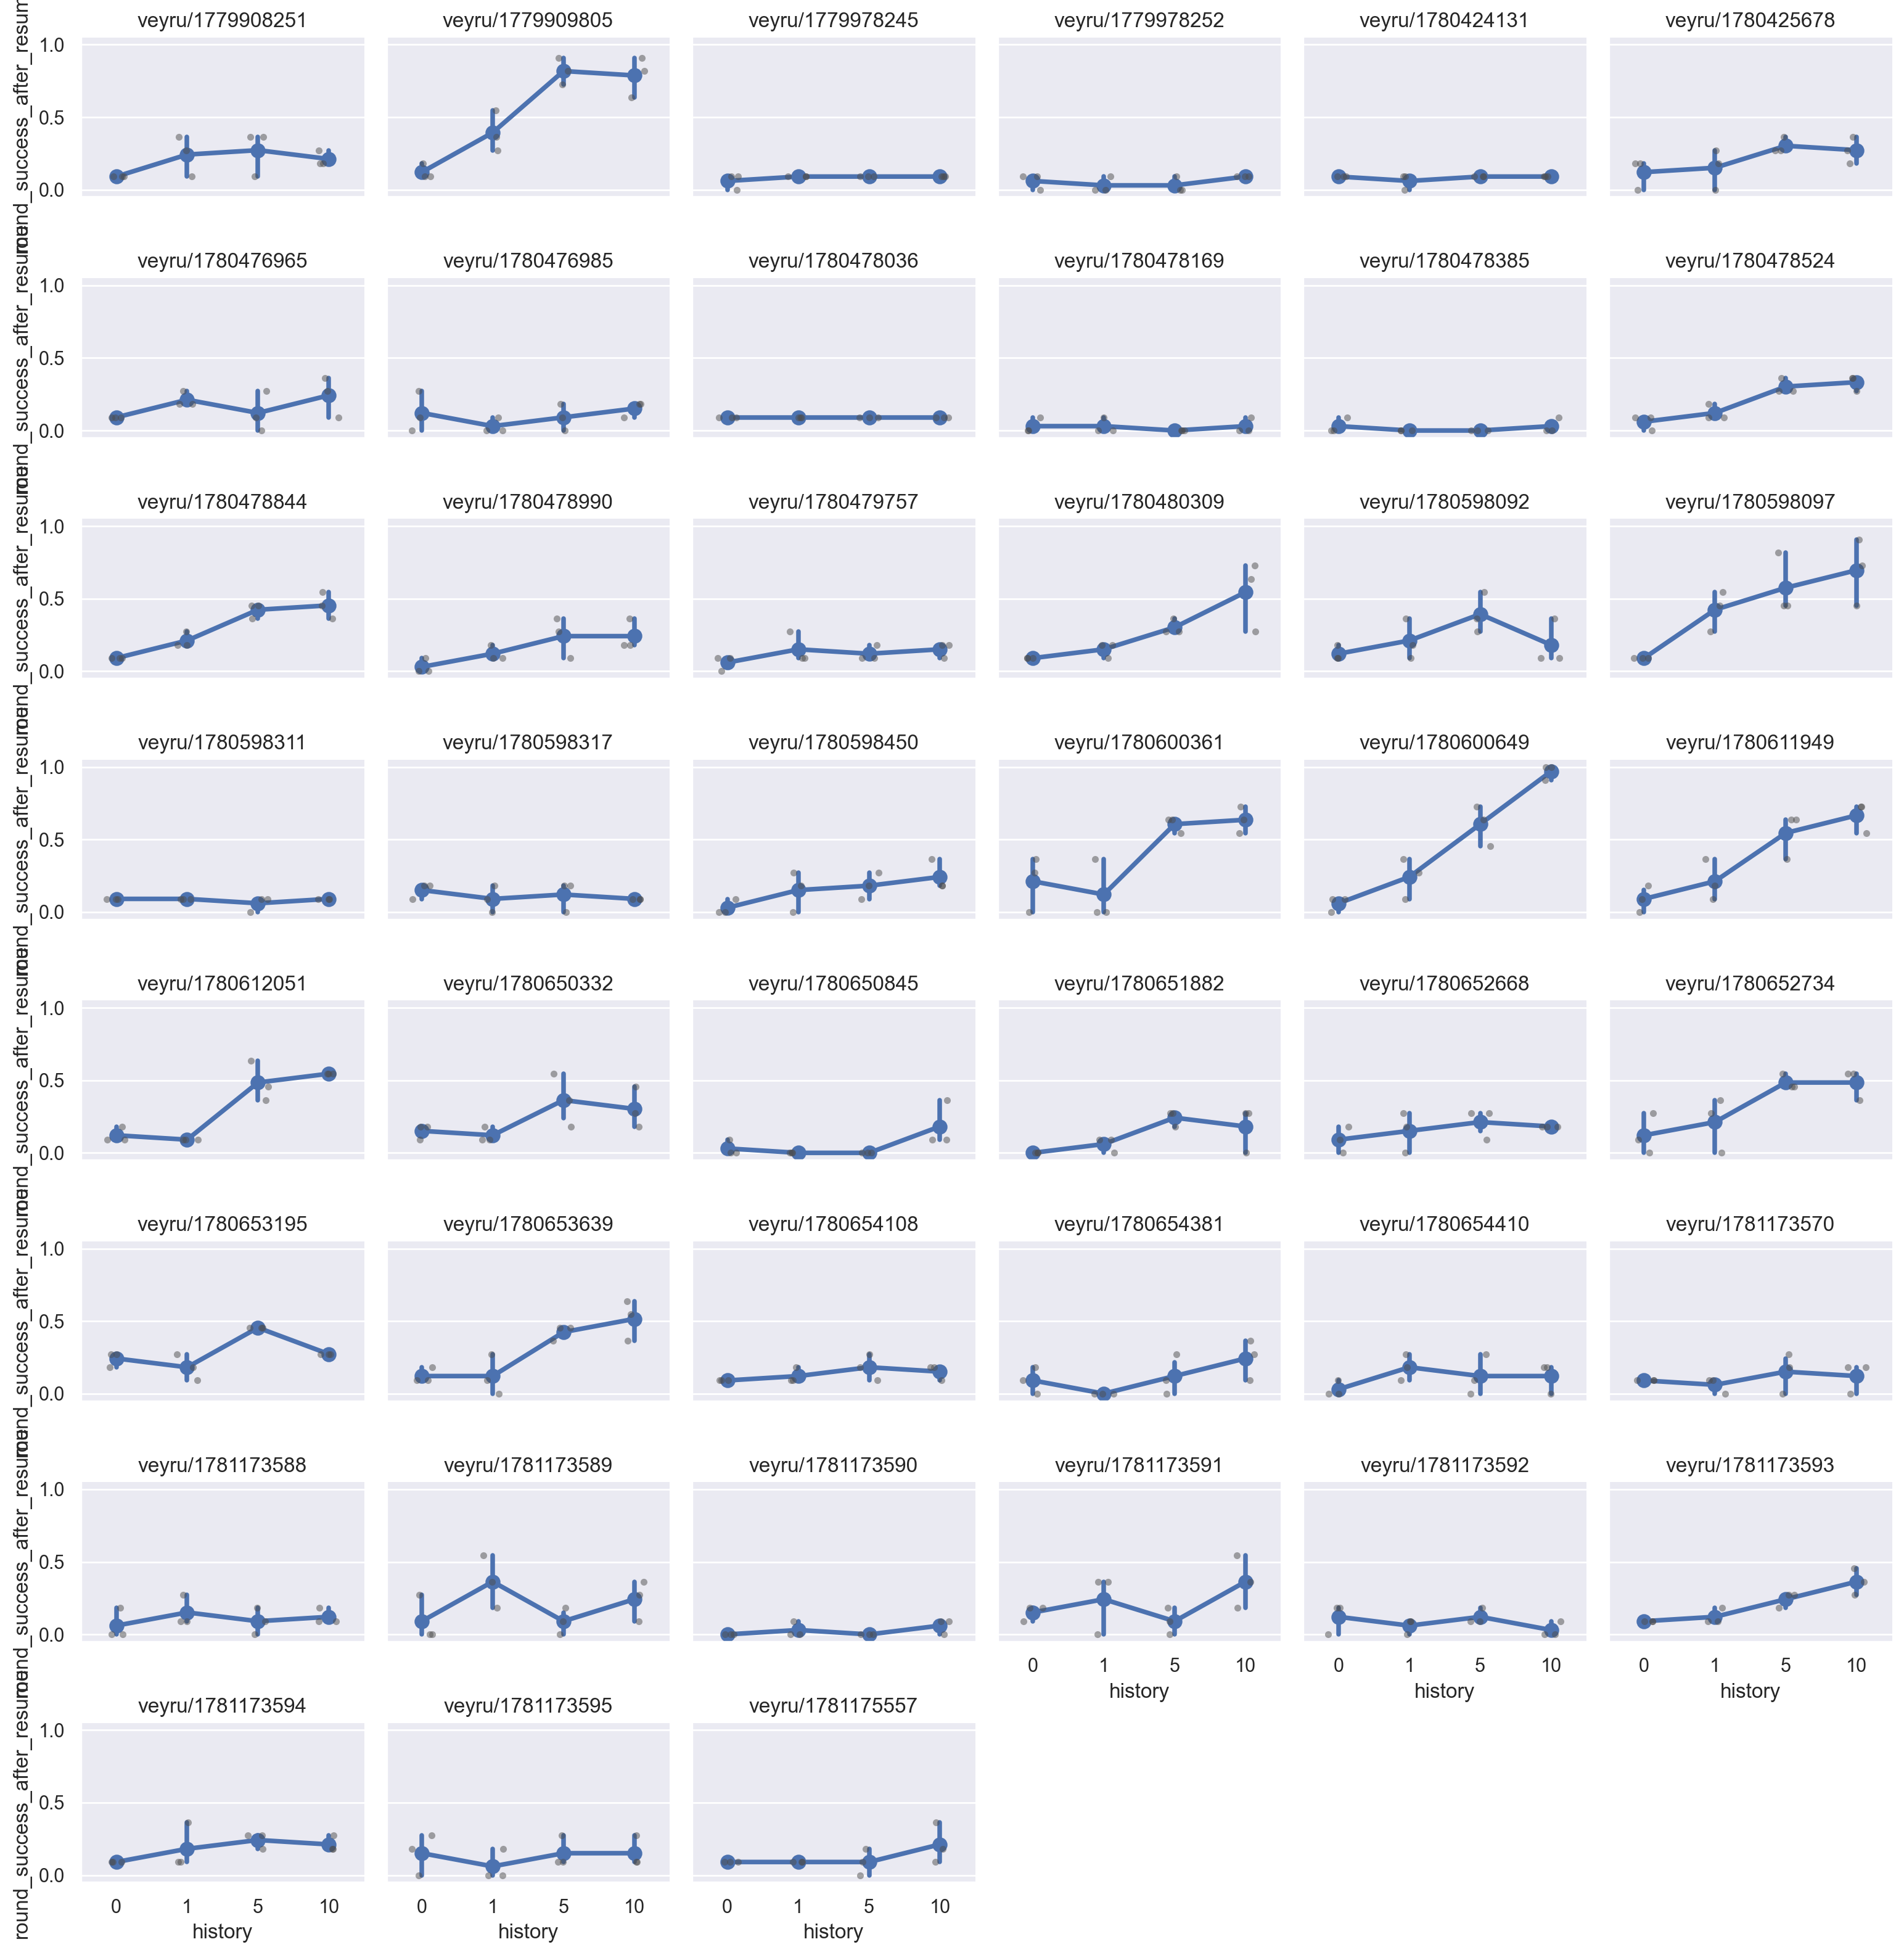

In [6]:
# Per-source-run learnability curves: round_success_after_resume vs history.
# One panel per src_id; history spans 0 (fresh agent) through 10.
# Individual replicas shown as jittered dots under the mean/CI line.
learned = data[data['phase'] == 'replace_learned'].copy()
learned['history'] = learned['history'].astype(int)

g = sns.FacetGrid(learned, col='src_id', col_wrap=6,
                  height=2.0, aspect=1.3, sharex=True, sharey=True)
g.map_dataframe(sns.stripplot, x='history', y='round_success_after_resume',
                order=[0, 1, 5, 10], color='.3', alpha=0.5, jitter=0.15, size=4)
g.map_dataframe(sns.pointplot, x='history', y='round_success_after_resume',
                order=[0, 1, 5, 10], errorbar=('ci', 95),
                color=sns.color_palette()[0])
g.set_titles('{col_name}')
g.set_axis_labels('history', 'round_success_after_resume')
plt.show()

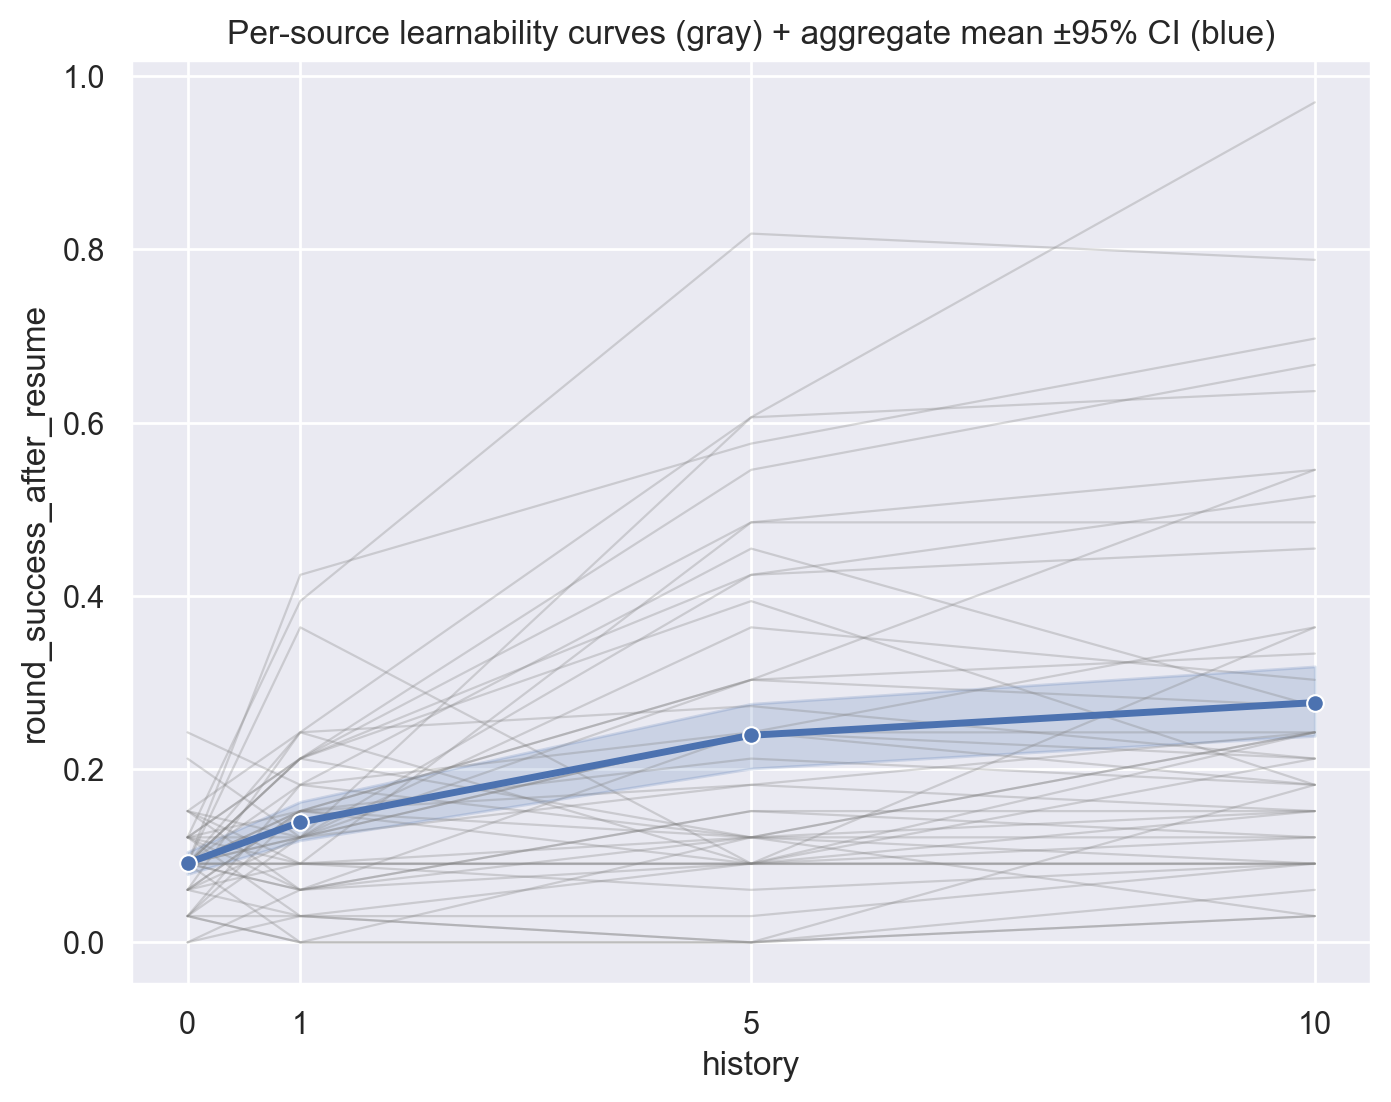

In [7]:
# Single-plot alternative to the facet grid: spaghetti plot.
# One faint gray line per source run (its mean curve across history),
# with the bold aggregate mean +/- 95% CI overlaid.
learned = data[data['phase'] == 'replace_learned'].copy()
learned['history'] = learned['history'].astype(int)
per_src = learned.groupby(['src_id', 'history'], as_index=False)['round_success_after_resume'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=per_src, x='history', y='round_success_after_resume', units='src_id',
             estimator=None, color='.5', alpha=0.3, linewidth=0.8, ax=ax, legend=False)
sns.lineplot(data=learned, x='history', y='round_success_after_resume',
             errorbar=('ci', 95), color=sns.color_palette()[0],
             linewidth=2.5, marker='o', ax=ax)
ax.set_xticks([0, 1, 5, 10])
ax.set_xlabel('history')
ax.set_ylabel('round_success_after_resume')
ax.set_title('Per-source learnability curves (gray) + aggregate mean ±95% CI (blue)')
plt.show()

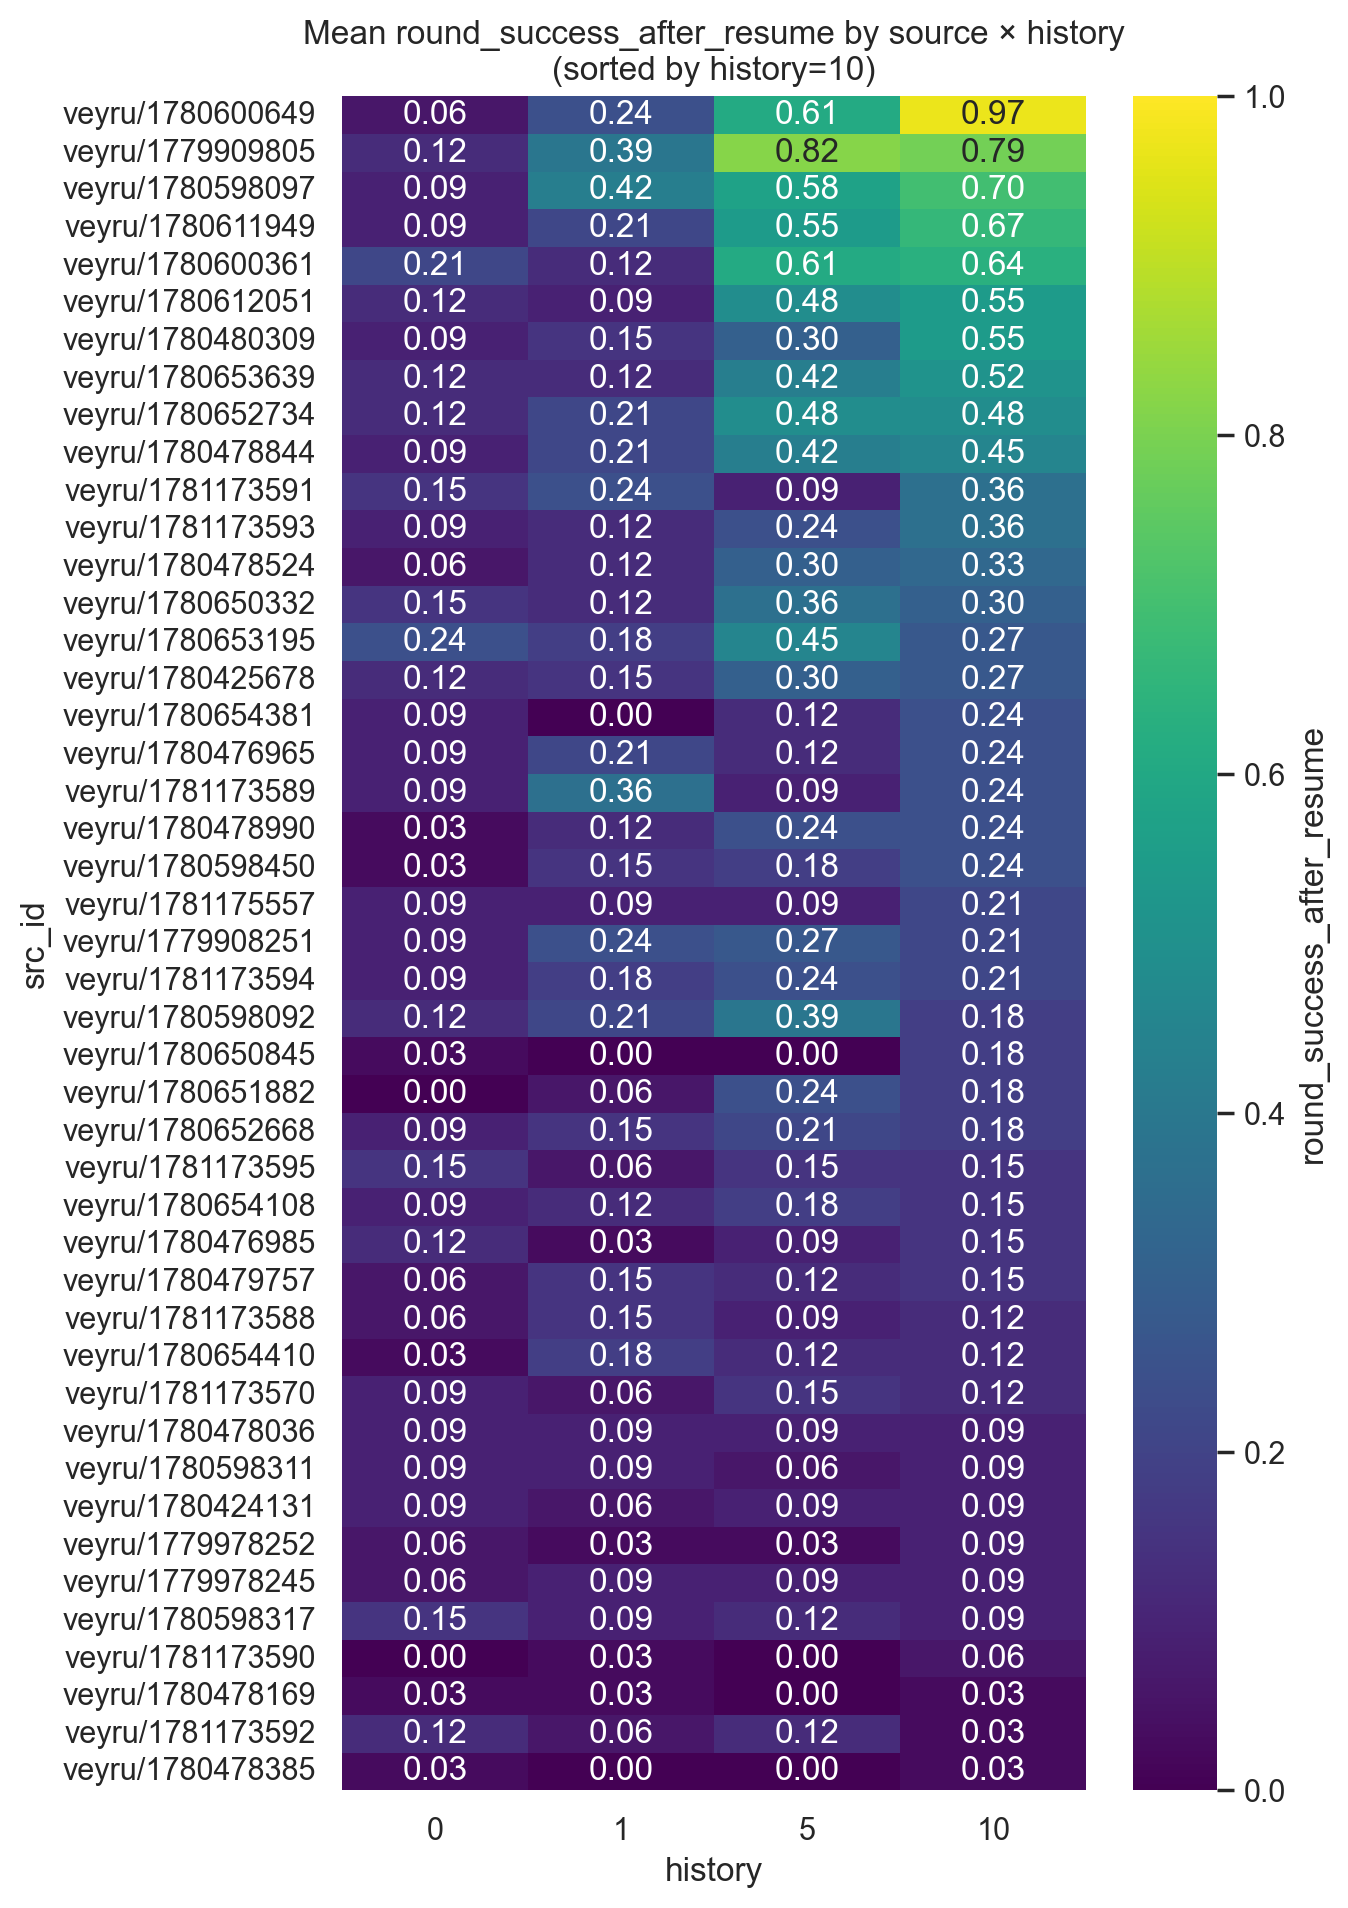

In [8]:
# Heatmap alternative: source x history matrix of mean round_success_after_resume,
# rows sorted by the history=10 outcome so learners sort to the top.
learned = data[data['phase'] == 'replace_learned'].copy()
learned['history'] = learned['history'].astype(int)
mat = (learned.groupby(['src_id', 'history'], as_index=False)['round_success_after_resume']
       .mean()
       .pivot(index='src_id', columns='history', values='round_success_after_resume')
       .sort_values(10, ascending=False))

fig, ax = plt.subplots(figsize=(6, 11))
sns.heatmap(mat, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
            cbar_kws={'label': 'round_success_after_resume'}, ax=ax)
ax.set_xlabel('history')
ax.set_ylabel('src_id')
ax.set_title('Mean round_success_after_resume by source × history\n(sorted by history=10)')
plt.show()

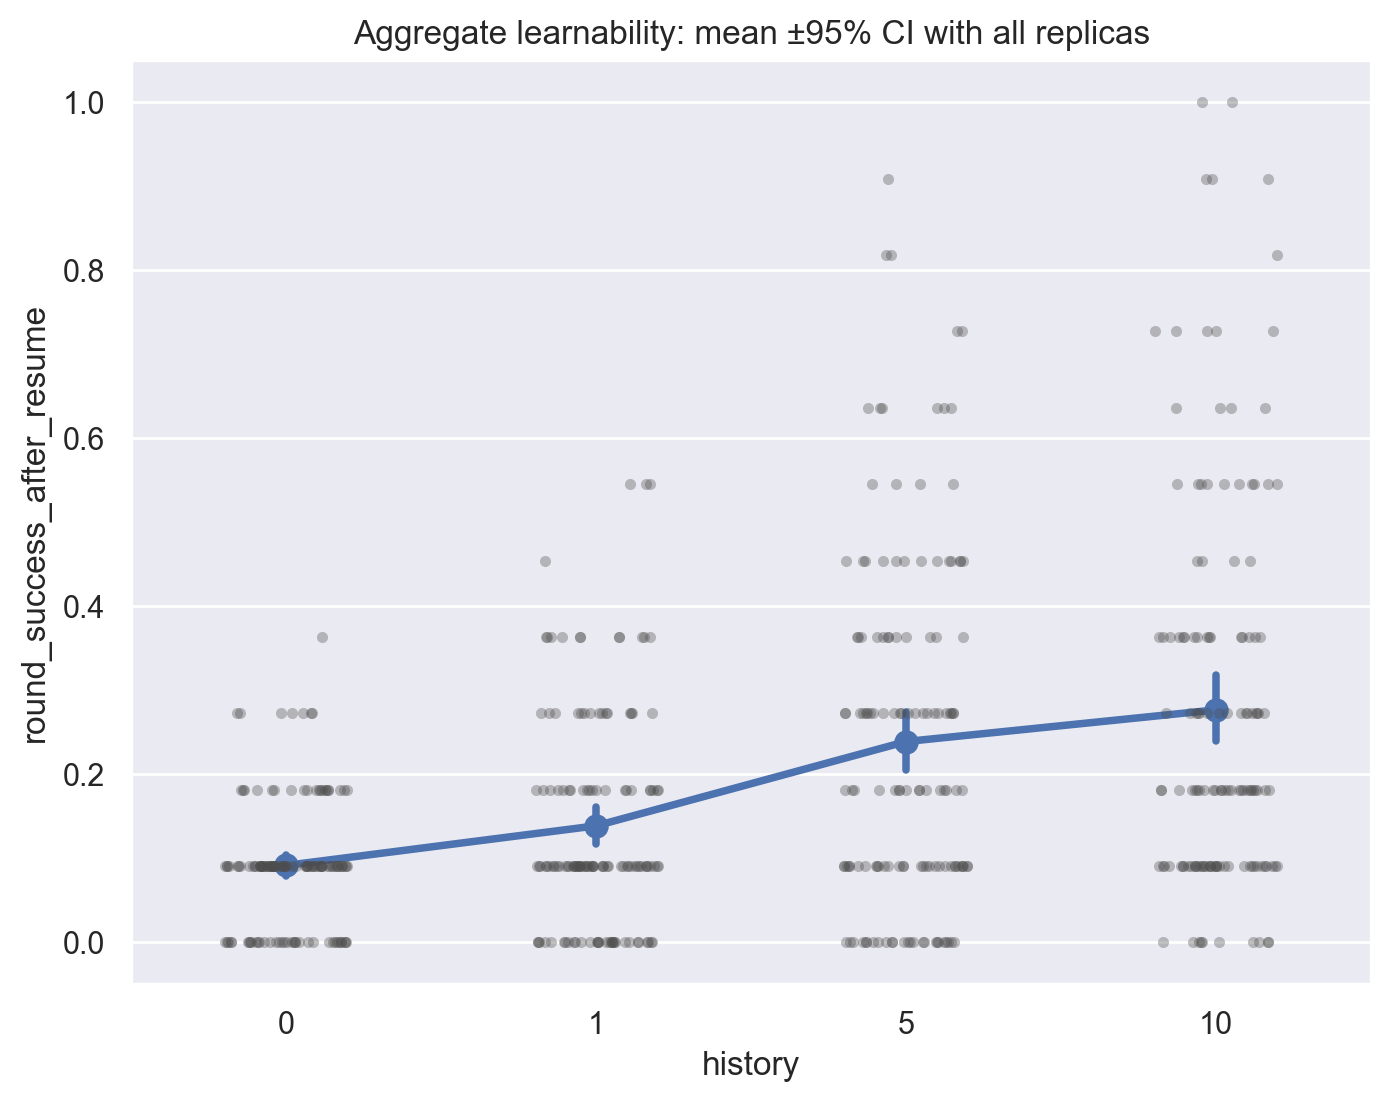

In [9]:
# Aggregate-only alternative: single mean ±95% CI curve across history,
# pooling all source runs, with every replica drawn as a jittered dot.
learned = data[data['phase'] == 'replace_learned'].copy()
learned['history'] = learned['history'].astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=learned, x='history', y='round_success_after_resume', order=[0, 1, 5, 10],
              color='.3', alpha=0.35, jitter=0.2, size=4, ax=ax)
sns.pointplot(data=learned, x='history', y='round_success_after_resume', order=[0, 1, 5, 10],
              errorbar=('ci', 95), color=sns.color_palette()[0], ax=ax)
ax.set_xlabel('history')
ax.set_ylabel('round_success_after_resume')
ax.set_title('Aggregate learnability: mean ±95% CI with all replicas')
plt.show()